# Notebook for analysing the PV and Charging Outputs

In [12]:
# Imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os

In [ ]:
# Set all Paths
stations: str = "best-ebus/scenario/sumo/electric/e_stations.add.xml"
station_output: str = "best-ebus/scenario/sumo/output/electric_bus_2026-07-14-09-31-34_chargingsstations.csv"
pv: str = "best-ebus/scenario/eBuS/files/solar_expanded.csv"

g:\Dokumente\Studium\FU Berlin\BeSTeBuS\best-ebus\scenario\eBuS\analysis


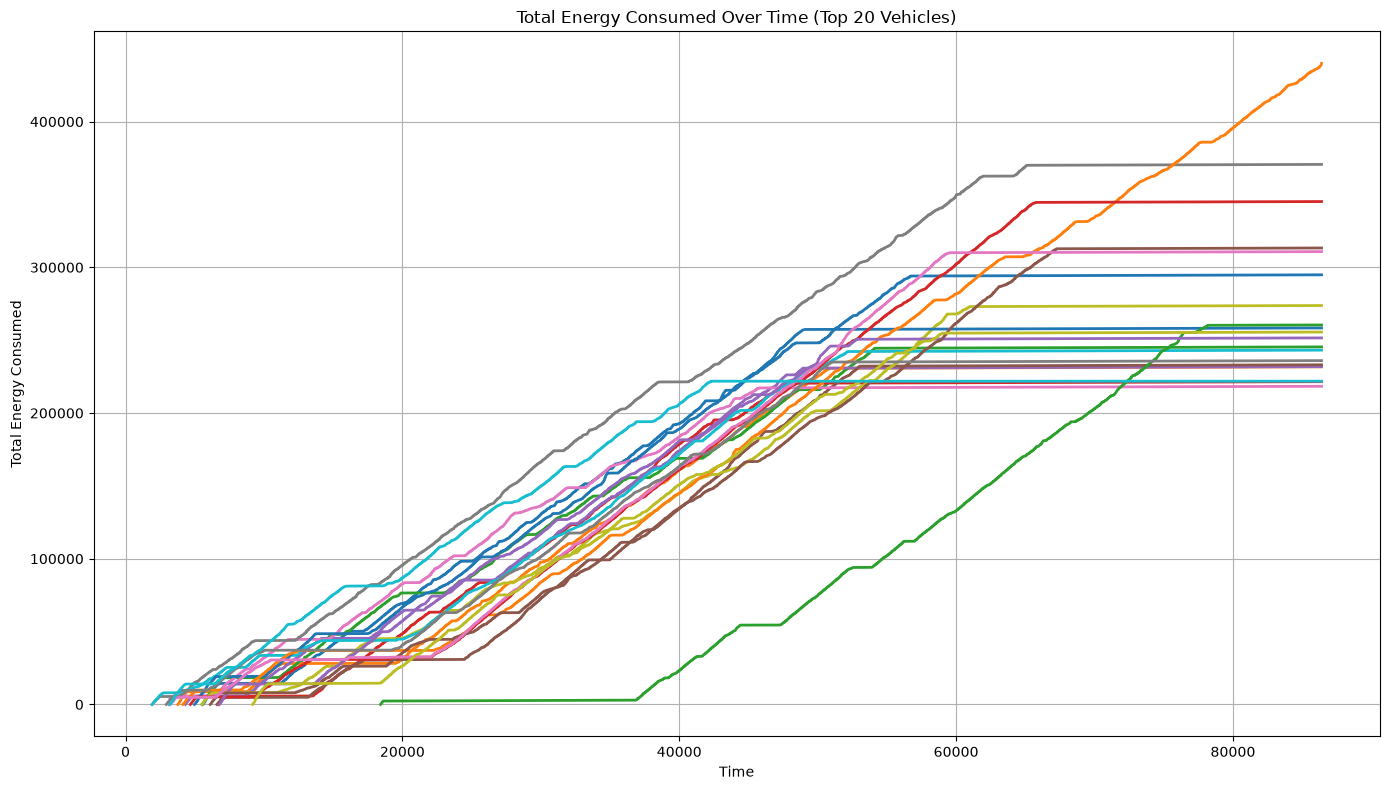

In [14]:
def plot_top_total_energy():
    print(os.getcwd())
    # Load the data
    df = pd.read_csv("../../sumo/output/electric_bus_2026-07-14-09-31-34_battery.csv", sep=";")

    # Ensure data is ordered by time
    df = df.sort_values(["vehicle_id", "timestep_time"])

    # Get the 20 vehicles with the highest total energy consumption
    # (using the final value of the cumulative total)
    top20_ids = (
        df.groupby("vehicle_id")["vehicle_totalEnergyConsumed"]
        .max()
        .nlargest(20)
        .index
    )

    # Keep only those vehicles
    top20_df = df[df["vehicle_id"].isin(top20_ids)]

    # Plot
    plt.figure(figsize=(14, 8))

    for vehicle_id, group in top20_df.groupby("vehicle_id"):
        plt.plot(
            group["timestep_time"],
            group["vehicle_totalEnergyConsumed"],
            linewidth=2,
            label=f"Vehicle {vehicle_id}"
        )

    plt.title("Total Energy Consumed Over Time (Top 20 Vehicles)")
    plt.xlabel("Time")
    plt.ylabel("Total Energy Consumed")
    plt.grid(True)
    plt.legend(title="Vehicle ID", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.legend().remove()
    plt.tight_layout()
    plt.show()

plot_top_total_energy()

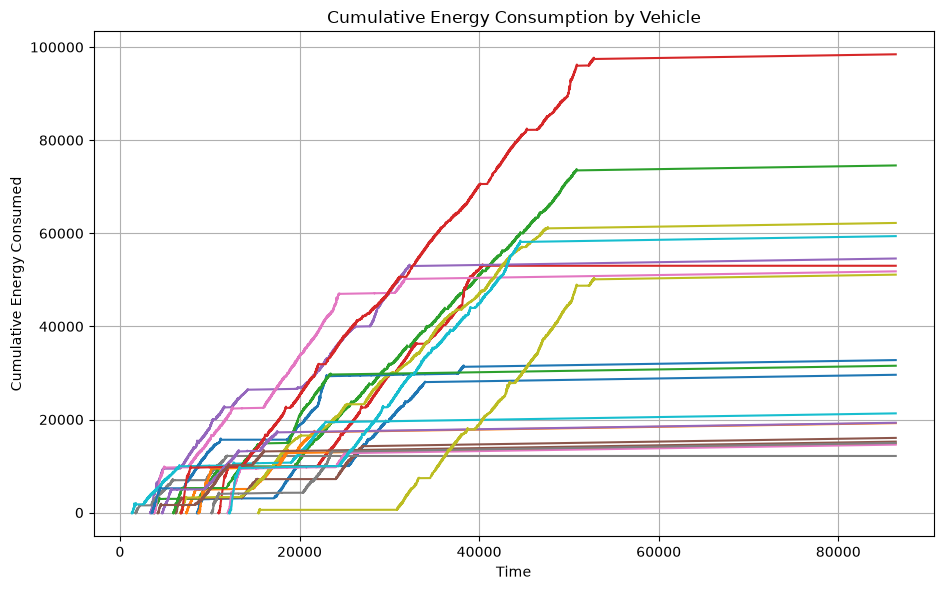

In [17]:
def plot_rand_20():
    df = pd.read_csv("../../sumo/output/electric_bus_2026-07-14-09-31-34_battery.csv", sep=";")
    df = df.sort_values(["vehicle_id", "timestep_time"])

    plt.figure(figsize=(12, 6))

    selected_ids = df["vehicle_id"].drop_duplicates().sample(n=20, random_state=42)

    for vehicle_id, group in df[df["vehicle_id"].isin(selected_ids)].groupby("vehicle_id"):
        cumulative = group["vehicle_energyConsumed"].cumsum()

        plt.plot(
            group["timestep_time"],
            cumulative,
            label=f"Vehicle {vehicle_id}"
        )

    plt.xlabel("Time")
    plt.ylabel("Cumulative Energy Consumed")
    plt.title("Cumulative Energy Consumption by Vehicle")
    plt.legend(title="Vehicle ID", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.legend().remove()
    plt.show()

plot_rand_20()


In [ ]:
def plot_solar_generation

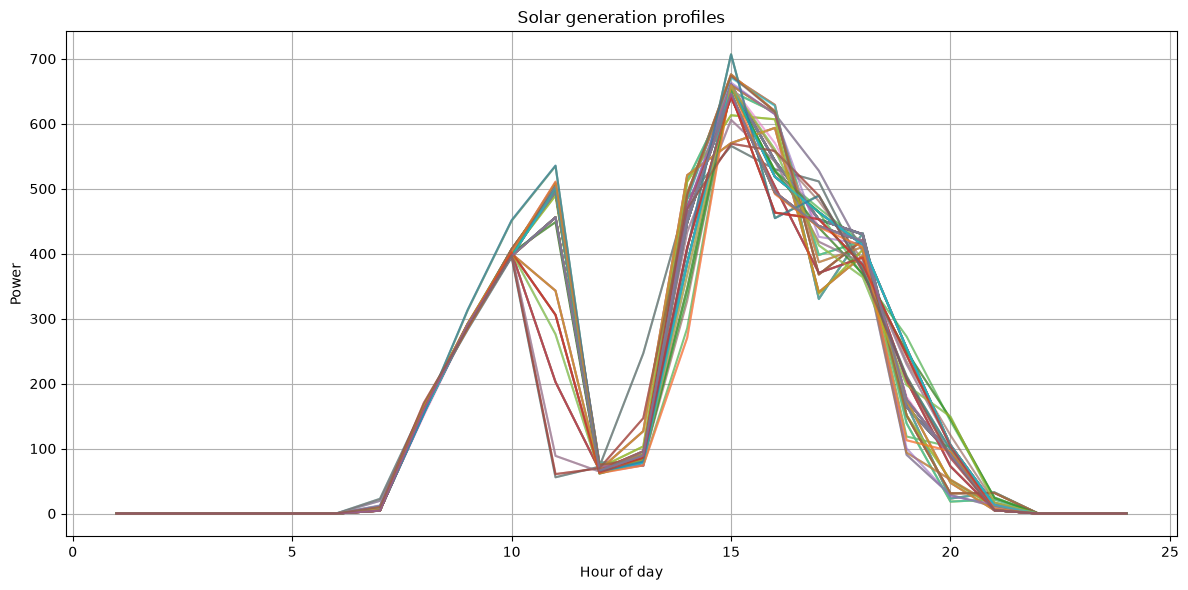

In [18]:
def plot_all_stations(df: pd.DataFrame):
    timestep_cols = sorted(
        [c for c in df.columns if c != "station_id"],
        key=int
    )

    x = [int(c) / 3600 for c in timestep_cols]

    plt.figure(figsize=(12, 6))

    for _, row in df.iterrows():
        plt.plot(x, row[timestep_cols], alpha=0.6, label=row["station_id"])

    plt.xlabel("Hour of day")
    plt.ylabel("Power")
    plt.title("Solar generation profiles")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

df = pd.read_csv("../files/solar_expanded.csv")
plot_all_stations(df)

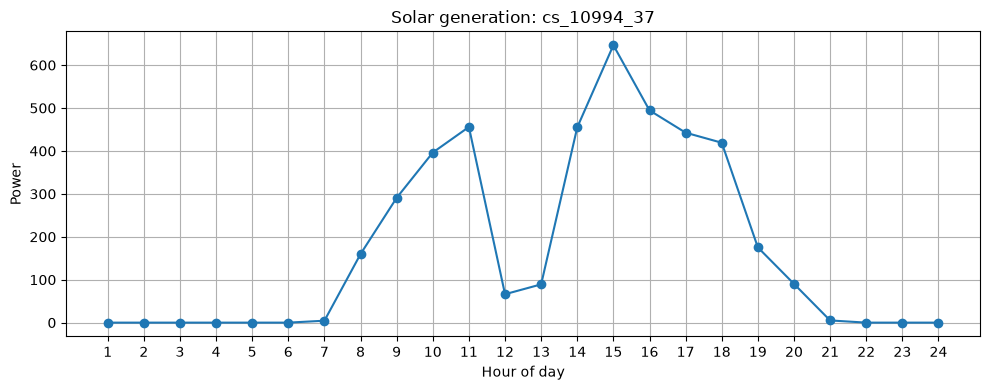

In [20]:
def plot_station_generation(df: pd.DataFrame, station_id: str):
    """
    Plot the hourly solar generation profile for a station.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with one row per station and timestep columns
        (e.g. 3600, 7200, ..., 86400).
    station_id : str
        ID of the station to plot.
    """
    row = df.loc[df["station_id"] == station_id]

    if row.empty:
        raise ValueError(f"Station '{station_id}' not found.")

    # timestep columns (everything except station_id)
    timestep_cols = [c for c in df.columns if c != "station_id"]

    # ensure they are sorted numerically
    timestep_cols = sorted(timestep_cols, key=int)

    x = [int(c) / 3600 for c in timestep_cols]  # hours
    y = row[timestep_cols].iloc[0].values

    plt.figure(figsize=(10, 4))
    plt.plot(x, y, marker="o")
    plt.xlabel("Hour of day")
    plt.ylabel("Power")
    plt.title(f"Solar generation: {station_id}")
    plt.xticks(range(1, 25))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

df = pd.read_csv("../files/solar_expanded.csv")
plot_station_generation(df, "cs_10994_37")